# Mustache Detector v2
Förbättringar mot v1:
- Clean-klassen inkluderar nu män med skägg men UTAN mustasch
- Data augmentation med rotation, flip, zoom, brightness
- Dropout för regularisering

In [1]:
import pandas as pd
import os
import shutil
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

print('TensorFlow:', tf.__version__)

TensorFlow: 2.16.2


## Ladda labels

In [2]:
labels = pd.read_csv('data/list_attr_celeba.csv')
source_dir = 'data/img/img_align_celeba'

men = labels[labels['Male'] == 1]
print('Totalt män:', len(men))

Totalt män: 84434


## Förbättrat urval
**V1:** clean = rakad (No_Beard=1) → modellen ser aldrig skägg utan mustasch

**V2:** clean = ingen mustasch, oavsett skägg → mer realistiskt

In [3]:
mustache_df = men[men['Mustache'] == 1]

# V2: tar bort No_Beard-kravet — inkluderar män med skägg men utan mustasch
clean_df = men[men['Mustache'] == -1]

print('Mustasch:', len(mustache_df))
print('Ingen mustasch (v2):', len(clean_df))

Mustasch: 8414
Ingen mustasch (v2): 76020


In [4]:
mustache_sample = mustache_df.sample(n=4000, random_state=42)
clean_sample    = clean_df.sample(n=4000, random_state=42)

print('Mustasch sample:', len(mustache_sample))
print('Clean sample:', len(clean_sample))

Mustasch sample: 4000
Clean sample: 4000


## Kopiera bilder till nytt dataset

In [5]:
os.makedirs('data/dataset_v2/mustache', exist_ok=True)
os.makedirs('data/dataset_v2/clean', exist_ok=True)

for filename in mustache_sample['image_id']:
    src = os.path.join(source_dir, filename)
    dst = os.path.join('data/dataset_v2/mustache', filename)
    if os.path.exists(src):
        shutil.copy2(src, dst)

for filename in clean_sample['image_id']:
    src = os.path.join(source_dir, filename)
    dst = os.path.join('data/dataset_v2/clean', filename)
    if os.path.exists(src):
        shutil.copy2(src, dst)

print('Mustache:', len(os.listdir('data/dataset_v2/mustache')))
print('Clean:', len(os.listdir('data/dataset_v2/clean')))

Mustache: 4000
Clean: 4000


## Ladda dataset

In [6]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    'data/dataset_v2',
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    'data/dataset_v2',
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

print('Klasser:', train_ds.class_names)

Found 8000 files belonging to 2 classes.
Using 6400 files for training.
Found 8000 files belonging to 2 classes.
Using 1600 files for validation.
Klasser: ['clean', 'mustache']


## Bygg modellen v2
Samma CNN-arkitektur som v1 men med augmentation och dropout

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),   # ±36 grader — hjälper med vinklade huvuden
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

model_v2 = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Träna

In [8]:
model_v2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 39s 188ms/step - accuracy: 0.5380 - loss: 0.6906 - val_accuracy: 0.5738 - val_loss: 0.6785
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 38s 187ms/step - accuracy: 0.6212 - loss: 0.6461 - val_accuracy: 0.7450 - val_loss: 0.5417
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 38s 188ms/step - accuracy: 0.7067 - loss: 0.5815 - val_accuracy: 0.7575 - val_loss: 0.5134
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 37s 186ms/step - accuracy: 0.7467 - loss: 0.5396 - val_accuracy: 0.7775 - val_loss: 0.4727
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 37s 186ms/step - accuracy: 0.7623 - loss: 0.5110 - val_accuracy: 0.7825 - val_loss: 0.4700
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 37s 183ms/step - accuracy: 0.7598 - loss: 0.5070 - val_accuracy: 0.7869 - val_loss: 0.4571
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 37s 186ms/step - accuracy: 0.7736 - loss: 0.4850 - val_accuracy: 0.7919 - val_loss: 0.4594
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 38s 189ms/step - accuracy: 0.7781 - loss: 0

## Utvärdering

In [9]:
loss, acc = model_v2.evaluate(val_ds)
print(f'V1 accuracy: 90.9%')
print(f'V2 accuracy: {acc*100:.1f}%')

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8319 - loss: 0.3894
V1 accuracy: 90.9%
V2 accuracy: 83.2%


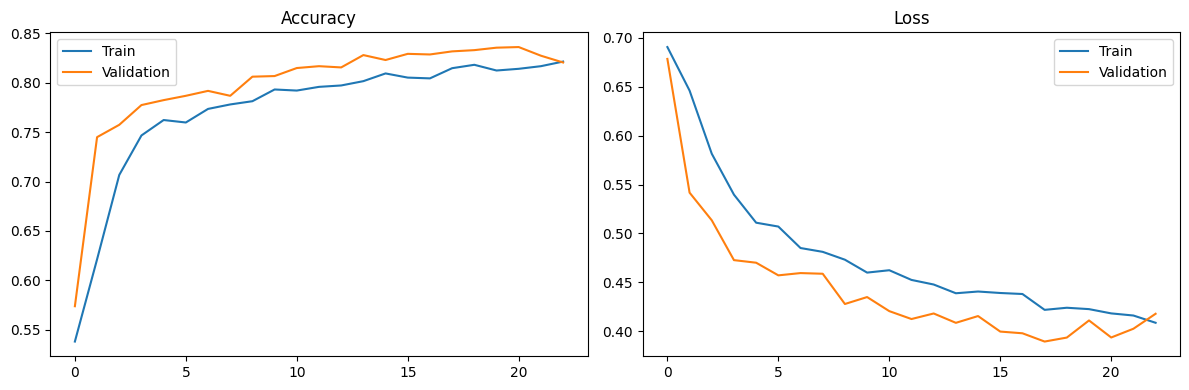

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

2026-06-02 17:53:16.687954: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


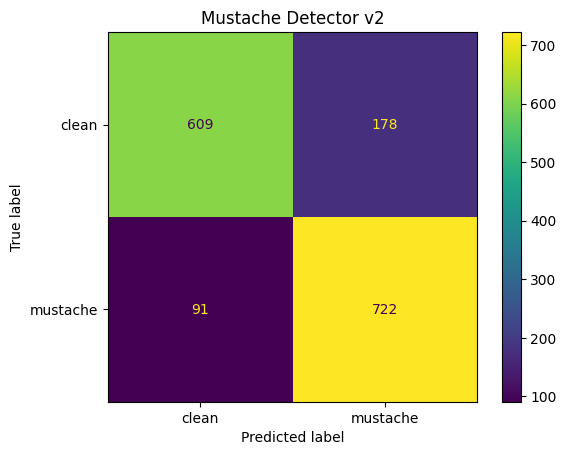

In [11]:
y_true, y_pred = [], []

for images, labels_batch in val_ds:
    preds = model_v2.predict(images, verbose=0).flatten()
    y_true.extend(labels_batch.numpy().astype(int))
    y_pred.extend((preds > 0.5).astype(int))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=val_ds.class_names
)
disp.plot(values_format='d')
plt.title('Mustache Detector v2')
plt.show()

## Spara — skriver över mustache_detector.keras
Kör bara denna om v2 är bättre än v1!

In [12]:
model_v2.save('models/mustache_detector2.keras')
print('Sparad!')

Sparad!
